# Limit contours: event list → excluded $(m_\text{DM}, \alpha_n)$ regions

**Private.** Successor to `12_limit_atmos`, with the limit set by the public
[`optimum_interval`](https://github.com/tunnell/optimum_interval) package
instead of the $\langle N\rangle = 3$ rule, so observed candidate events are
handled without a background model.

**Input:** the `EVENTS` array of reconstructed kick momenta (here one random
toy candidate). *Replacing that array with data is the only change needed to
run the real analysis.* **Output:** the 95% CL excluded
$(m_\text{DM}, \alpha_n)$ regions for the **seven planned mediator ranges**,

$$\lambda = 2\ \text{m},\ 2\ \text{cm},\ 2\ \text{mm},\ 200\ \text{µm},\
20\ \text{µm},\ 10\ \text{µm},\ 2\ \text{µm}$$

($\xi \equiv R_\text{eff}/\lambda$ from $10^{-3}$ to $10^{2}$, sensor radius
$R_\text{eff}$ = 200 µm), plus the machine-readable `limit_contour_data.npz`.
Couplings run up to $\alpha_n = 1$ and masses up to the Planck mass. The rate
carries the **DM-fraction scaling $f_X$ = `config.F_X` = 0.1**: this species
is a tenth of the local dark matter density (evading self-interaction
constraints), which weakens every coupling limit by $\sqrt{10}$ relative to
$f_X = 1$.

The notebook is a pipeline, one section each:

1. **Physics model**: SHM halo at the top of the atmosphere (`luhdm.halo`);
   attenuation ODE → detector-frame $f(v)$ carrying the survival fraction
   (`luhdm.atmosphere`); classical $K_1$-impulse cross section from a
   finite-range Yukawa on the finite-size magnet (`luhdm.cross_section`; the
   shortest range uses its log-space variant, which stays finite where the
   direct Bessels degrade at large $\xi$); assembled into
   $dR/dq = n_\text{DM}\int f(v)\,v\,(d\sigma/dq)\,dv$ by
   `luhdm.rate.differential_rate_trapz`. The rate formulas live in
   **`luhdm/rate.py`**, imported by this notebook *and* by the remote-node scripts
   (`scripts/scan_grid.py`, `scripts/make_maps.py`), so the two can never
   drift; that module is where the physics gets tweaked.
2. **Statistics**: at each $(m_\text{DM}, \alpha_n)$ grid point, the expected
   count $\mu$ and normalized spectrum shape feed the optimum-interval
   **extremeness** (`luhdm.limits`). Because the spectrum shape itself depends
   on the coupling (finite range, attenuation), the limit is a **level set of
   the extremeness surface**, not a single $\mu$ solve.
3. **Results**: the extremeness surface at the reference range
   $\lambda = R_\text{eff}$, then all seven 95% contours.
4. **Understanding**: why the islands look the way they do, plus
   transit-count and reach maps up to the Planck mass. *Pedagogical: nothing
   there feeds the limit.*
5. **Output**: `limit_contour_data.npz`: grids, surfaces, contour polylines.

**Cache-or-compute:** every expensive product has an npz cache generated by a
script through the same `luhdm.rate` calls. If `scan7_<tag>.npz` /
`flux_maps.npz` sit next to this notebook they are loaded; delete them and the
notebook regenerates everything inline (a coarse scan for the reference range,
full-resolution maps).
6. **Appendix**: validation against closed forms and spot checks along the
   reference contour.


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import atmosphere, config, cross_section, halo, limits, units

R_eff = config.R_EFF             # 200 um
Q_THRESH = config.Q_THRESH
T_TOTAL = 3600 * 24 * 7 * 2      # 2 weeks in seconds
CONFIDENCE = 0.95
M_PLANCK = 1.22e19               # GeV

# the seven planned mediator ranges, largest first. The family is ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2m", "2cm", "2mm", "200um", "20um", "10um", "2um"]
_LAMBS = [2.0, 2e-2, 2e-3, 2e-4, 2e-5, 1e-5, 2e-6]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = {"2um"}                   # loaded and exported, but not drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si} = ${x / 10**e:.1f}\times10^{{{e}}}$ GeV$^{{-1}}$"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


np.random.seed(20260702)         # luhdm samplers use legacy np.random
print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_X = {config.F_X}")

N_n = 2.51e+20   q_th = 8400 GeV   R_eff = 200 um   f_X = 0.1


## Input: the event list

One candidate kick drawn at random just above threshold. **Replace this array
with the reconstructed kicks from data and rerun; nothing else changes.**


In [2]:
rng = np.random.default_rng(20260702)
EVENTS = 10 ** rng.uniform(np.log10(Q_THRESH), np.log10(3 * Q_THRESH), size=1)
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12625.]


## Physics model

### Cross-section handles

One handle per mediator range via `luhdm.rate.make_xsec`: Dorian's direct
tabulation for $\xi = R_\text{eff}/\lambda \le 30$, the log-space variant
beyond (the direct Bessels degrade and then underflow, $K_1(1000) = 0$ in
float64; agreement is pinned by `tests/test_cross_section_ln.py`), and
`lamb=None` for the **massless analytic limit**
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$
(`cross_section.cross_section_rutherford_projection`), used as a reference
line throughout.


In [3]:
import os
os.environ["TQDM_DISABLE"] = "1"

from luhdm import rate

XSEC = {}
for tag, lamb, color in LAMBDAS:
    t0 = time.time()
    XSEC[tag] = rate.make_xsec(lamb)
    XSEC[tag]["color"] = color
    print(f"{tag:>6}: xi = {R_eff / lamb:8.3f}  "
          f"{'log-space' if XSEC[tag]['use_ln'] else 'direct':>9}"
          f"  ({time.time() - t0:.0f}s)")
XS_MASSLESS = rate.make_xsec(None)   # analytic Rutherford projection
print("massless: analytic (no tabulation)")

  0%|          | 0/600 [00:00<?, ?it/s]

~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The maximum number of subdivisions (100) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  result, _ = quad(integrand, 0, t_max, limit=100)
~/code/luhdm/luhdm/cross_section.py:302: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  result, _ = quad(integrand, 0, t_max, limit=100)
  0%|          | 2/600 [00:00<00:34, 17.29it/s]

  1%|          | 4/600 [00:00<00:34, 17.30it/s]

  1%|          | 6/600 [00:00<00:33, 17.94it/s]

  1%|▏         | 8/600 [00:00<00:32, 18.30it/s]

...

 97%|█████████▋| 584/600 [00:22<00:00, 32.53it/s]

 98%|█████████▊| 589/600 [00:23<00:00, 35.81it/s]

 99%|█████████▉| 594/600 [00:23<00:00, 37.24it/s]

100%|██████████| 600/600 [00:23<00:00, 25.79it/s]

  10um: xi =   20.000     direct  (23s)
   2um: xi =  100.000  log-space  (0s)
massless: analytic (no tabulation)


### Differential rate

$dR/dq$ and the companion flux integral (`expected_transits`, used in the
Understanding section and the appendix) come from `luhdm.rate`, with the same
formula and notation as `12_limit_atmos` (`mu` is the DM mass in the original
notation). The scan scripts call these exact functions.


In [4]:
v_i_samples = atmosphere.sample_shm(int(1e5))  # SHM at the top of the atmosphere

# thin aliases so the cells below read like the original notebook
def differential_rate_trapz(qs, alpha_n, mu, f_v_f, xs):
    return rate.differential_rate_trapz(qs, alpha_n, mu, f_v_f, xs)

def expected_transits(alpha_n, mu, f_v_f, xs):
    return rate.expected_transits(alpha_n, mu, f_v_f, xs, T_TOTAL)

### Spectra

The attenuated $dR/dq$ for all seven ranges at a fixed mass and coupling. At
fixed coupling the spectrum weakens and steepens as the range shrinks (the
momentum cap $\tilde q < K_1(\xi)$ bites); the longest ranges sit on the
**massless analytic curve** (black dashed,
$d\sigma/dq = 2\pi\alpha^2/(v^2q^3)$), with the endpoint at the halo
kinematic limit.


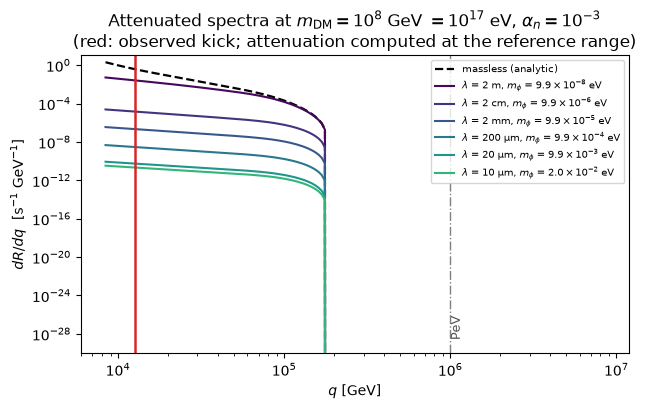

In [5]:
ALPHA_N_SHOW = 1e-3
M_SHOW = 1e8
qs_plot = np.geomspace(Q_THRESH, 1000 * Q_THRESH, 160)

v_min_show = qs_plot.min() / M_SHOW / 10
v_f_show = atmosphere.compute_v_f_distribution(
    ALPHA_N_SHOW, LAMB_REF, M_SHOW, v_i_samples, v_min=v_min_show, n_grid=80)
f_v_f_show = atmosphere.compute_f_vf(v_f_show, v_min_show)[0]

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(qs_plot,
          differential_rate_trapz(qs_plot, ALPHA_N_SHOW, M_SHOW,
                                  f_v_f_show, XS_MASSLESS),
          color="k", ls="--", lw=1.6, label="massless (analytic)")
for tag, lamb, color in LAMBDAS:
    if tag in HIDE:
        continue
    ax.loglog(qs_plot,
              differential_rate_trapz(qs_plot, ALPHA_N_SHOW, M_SHOW,
                                      f_v_f_show, XSEC[tag]),
              color=color, label=range_legend(lamb))
for q_ev in EVENTS:
    ax.axvline(q_ev, color="#d62728", lw=1.8)
ax.set_ylim(bottom=1e-30)
ax.set_xlabel(r"$q$ [GeV]")
ax.set_ylabel(r"$dR/dq$  [s$^{-1}$ GeV$^{-1}$]")
ax.axvline(1e6, color="#7f7f7f", lw=1.0, ls="-.")
ax.text(1e6, 0.03, " PeV", color="#555555", fontsize=9, ha="left",
        va="bottom", rotation=90, transform=ax.get_xaxis_transform())
ax.set_title(rf"Attenuated spectra at $m_{{\rm DM}} = 10^8$ GeV $= 10^{{17}}$ eV, "
             rf"$\alpha_n = 10^{{-3}}$" + "\n(red: observed kick; "
             "attenuation computed at the reference range)")
ax.legend(fontsize=7)
fig.tight_layout()

## Statistics: what the extremeness means

At each grid point the extremeness is

$$p = \Pr\big(C_\text{max}^\text{pseudo} < C_\text{max}^\text{obs}\,\big|\,m_\text{DM}, \alpha_n,\ \text{no background}\big),$$

the fraction of background-free pseudo-experiments generated *under that
hypothesis* whose most-anomalously-empty spectral stretch looks **less** empty
than the data. Physically: $p = 0.95$ means the hypothesis predicts enough
events that 95% of the time our gaps would have been filled in more than they
are: the observed emptiness sits in the 5% tail, so the point is excluded at
95% CL. The surface *is* the confidence level: the rule "exclude where
$p \ge C$" wrongly rejects a true hypothesis at most $(1-C)$ of the time
(frequentist coverage, not a posterior probability), and any CL is a level set
of the same array; the 90% contour needs no rescan. The test is one-sided by
construction: background can only *add* events, filling gaps and lowering $p$,
so backgrounds can weaken an exclusion but never fake one.


## The $(m_\text{DM}, \alpha_n)$ scans

One scan per mediator range, from `scripts/scan_grid.py` run on a many-core
node (`--lamb <meters> --out scan7_<tag>.npz`); each stores three surfaces:
`counts` (expected events $\mu$), `extremeness`, and `n_transit`. Monte-Carlo
calibration tables are shared across the plane via $\mu$ rounding. If a scan
file is missing, a coarse inline scan runs for the reference range only.


In [6]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    f = Path(f"scan7_{tag}.npz")
    if not f.exists():
        print(f"{f} missing; skipping {tag}")
        continue
    d = np.load(f)
    assert np.allclose(d["events"], EVENTS), f"{f}: different event list!"
    if lamb is not None:
        assert np.isclose(float(d["lamb"]), lamb), f"{f}: lambda mismatch"
    else:
        assert bool(d["massless"]), f"{f}: expected a --massless scan"
    SCANS[tag] = dict(
        ms=d["ms"], alphas_n=d["alphas_n"], extremeness=d["extremeness"],
        counts=d["counts"], n_transit=np.maximum(d["n_transit"], 0.0),
        lamb=lamb, color=color)
    # (n_transit clip: the KDE tail can oscillate slightly negative below the
    # kinematic floor)
print(f"loaded {len(SCANS)}/{len(LAMBDAS)} scans")

REF_TAG = "200um"
if REF_TAG not in SCANS:
    # coarse inline fallback for the reference range
    ms = np.logspace(6.6, np.log10(M_PLANCK), 19)
    alphas_n = np.logspace(-8.5, 0.0, 30)
    counts = np.zeros((alphas_n.size, ms.size))
    extremeness = np.zeros((alphas_n.size, ms.size))
    N_T = np.zeros((alphas_n.size, ms.size))
    table = limits.new_table(seed=20260702)
    xs_ref = XSEC[REF_TAG]
    t0 = time.time()
    for im, m in enumerate(ms):
        for ia, alpha_n in enumerate(alphas_n):
            v_min = Q_THRESH / m / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                alpha_n, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            diff_rate = differential_rate_trapz(qs, alpha_n, m, f_v_f, xs_ref)
            extremeness[ia, im], counts[ia, im] = limits.extremeness_and_mu(
                table, EVENTS, qs, diff_rate, T_TOTAL)
            N_T[ia, im] = expected_transits(alpha_n, m, f_v_f, xs_ref)
    SCANS[REF_TAG] = dict(ms=ms, alphas_n=alphas_n, extremeness=extremeness,
                          counts=counts, n_transit=N_T, lamb=LAMB_REF,
                          color="#d62728")
    print(f"inline scan ({REF_TAG}): {time.time() - t0:.0f}s")

REF = SCANS[REF_TAG]

loaded 8/7 scans


## Results

### The reference range, $\lambda = R_\text{eff}$ = 200 µm

Solid: the 95% CL optimum-interval contour given `EVENTS`. Dashed: the
$\langle N\rangle = 3$ zero-event contour (the old rule) from the same
`counts` surface. The excluded region is an island; each edge is explained in
"Understanding" below.

Note the dashed contour pokes out past the red one near the floor and the
left edge: there the (narrow) kinematic window contains the observed kick, so
the honest one-event limit is weaker than the zero-event rule, which simply
does not apply once there is a candidate. Where the window excludes the event
the two coincide.


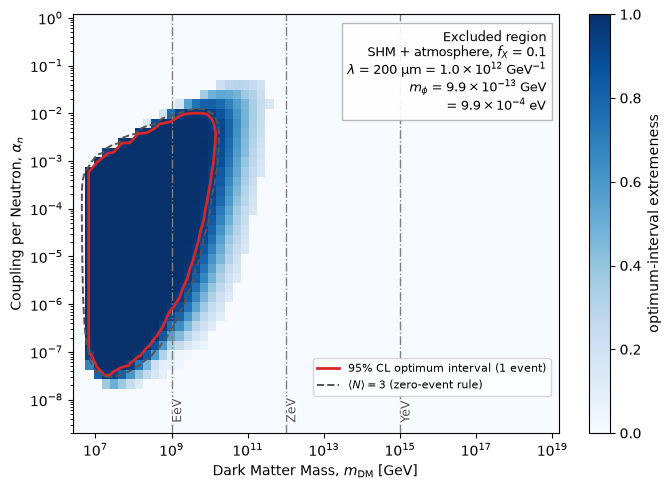

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(REF["ms"], REF["alphas_n"], REF["extremeness"],
                     cmap="Blues", vmin=0, vmax=1, shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
cs95 = ax.contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                  levels=[CONFIDENCE], colors="#d62728", linewidths=2)
cs3 = ax.contour(REF["ms"], REF["alphas_n"], REF["counts"], levels=[3.0],
                 colors="#555555", linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$ (zero-event rule)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), M_PLANCK)
ax.text(0.975, 0.965,
        "Excluded region\nSHM + atmosphere, $f_X$ = 0.1\n"
        + lamb_label(LAMB_REF) + "\n"
        + mphi_label(LAMB_REF, unit="GeV") + "\n"
        + "= " + mphi_label(LAMB_REF, unit="eV").split(" = ", 1)[1],
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="lower right", bbox_to_anchor=(0.995, 0.075), fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour.png", dpi=140)

### All seven ranges

The 95% CL contours for the seven planned ranges, with the single toy
candidate and atmospheric attenuation everywhere. Five ranges exclude; the
momentum cap $\tilde q_\text{max} = K_1(\xi)$ organizes the family:

- **Shared floor at long range.** The 2 m, 2 cm, and 2 mm islands share the
  same coupling floor, $\alpha_n \approx 2.0\times10^{-8}$ (Coulomb regime);
  200 µm and 20 µm pay the cap penalty ($3.3\times10^{-8}$ and
  $3.5\times10^{-5}$). All floors carry the $f_X^{-1/2}$ penalty of the
  subdominant density.
- **High-mass endpoints ladder by $\sim100\times$ per decade of $\lambda$**
  (reach saturation, $\sigma_\text{sat} \sim \lambda^2$, vs the falling
  number density $f_X/m$): $3.0\times10^{7}$ GeV (20 µm, now a sliver),
  $1.1\times10^{10}$ (200 µm), $1.6\times10^{12}$ (2 mm), $1.4\times10^{14}$
  (2 cm), $6.3\times10^{17}$ (2 m). Even the 2 m island closes well below the
  Planck mass.
- **The massless analytic line (black dashed) is the $\lambda\to\infty$
  ideal.** Its exclusion continues through the Planck-mass edge of the grid:
  flux quantization never closes an uncapped Coulomb reach. Its floor,
  $\alpha_n \approx 1.3\times10^{-8}$, sits below even the 2 m island's,
  because at floor couplings the 2 m momentum cap
  ($\tilde q_\text{max} = K_1(\xi)$) already bites; the sensor cross section
  is the analytic $2\pi\alpha^2/(v^2q^3)$, with the atmospheric Coulomb log
  regulated at 2 m.
- **The three shortest ranges exclude nothing or almost nothing.** The 20 µm
  island survives only as a sliver around $3\times10^{7}$ GeV; the 10 µm
  saturated rate tops out at $\mu \approx 2.4$ and 2 µm at 0.4, below the
  one-event 95% bar (at $f_X = 1$ the 10 µm channel would have been
  marginal; the tenfold density reduction plus attenuation close it). Honest
  nulls, not plotting gaps; the 2 µm case is omitted from the figures but
  kept in the scans and the data export.


    2m: m in [6.8e+06, 6.3e+17] GeV, alpha_n down to 2.0e-08
   2cm: m in [6.8e+06, 1.4e+14] GeV, alpha_n down to 2.0e-08
   2mm: m in [6.8e+06, 1.6e+12] GeV, alpha_n down to 2.0e-08
 200um: m in [6.8e+06, 1.1e+10] GeV, alpha_n down to 3.3e-08
  20um: m in [1.8e+07, 3.0e+07] GeV, alpha_n down to 3.5e-05
  10um: no exclusion (max p = 0.68, max mu = 2.38)
   2um: no exclusion (max p = 0.15, max mu = 0.38)
massless: m in [6.8e+06, 1.2e+19] GeV, alpha_n down to 1.3e-08


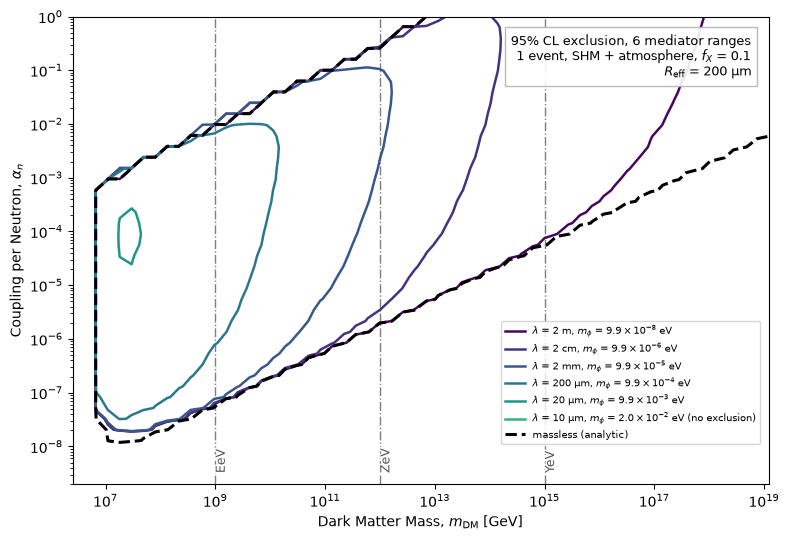

In [8]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS or tag in HIDE:
        continue
    s = SCANS[tag]
    style = dict(linestyles="--", linewidths=2.2) if lamb is None else \
        dict(linewidths=1.8)
    lab = ("massless (analytic)" if lamb is None
           else range_legend(lamb))
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color, **style)
        ax.plot([], [], color=color, lw=style["linewidths"],
                ls="--" if lamb is None else "-", label=lab)
    else:
        ax.plot([], [], color=color, lw=1.8, label=lab + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), M_PLANCK)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), M_PLANCK)
n_shown = len([t for t, _, _ in LAMBDAS if t not in HIDE])
ax.text(0.975, 0.965,
        f"{CONFIDENCE:.0%} CL exclusion, {n_shown} mediator ranges\n"
        f"{EVENTS.size} event, SHM + atmosphere, $f_X$ = 0.1\n"
        rf"$R_{{\rm eff}}$ = 200 µm",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="lower right", bbox_to_anchor=(0.995, 0.075), fontsize=7)
fig.tight_layout()
fig.savefig("limit_contour_all.png", dpi=140)

for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}")
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

### Sensitivity vs mediator range at the best mass

Fixing $m_\text{DM}$ at the most sensitive mass (the deepest point of the
reference-range coupling floor, $1.8\times10^{7}$ GeV) and scanning the
mediator range against the coupling, across all seven planned ranges (2 µm to
2 m) with the same coupling grid as the mass scans. The excluded band is
bounded below by the statistics floor, which deepens with range and levels
off at the Coulomb value $\alpha_n \approx 2\times10^{-8}$ once
$\lambda \gtrsim$ mm (the momentum cap stops mattering), and above by the
atmospheric ceiling at $\alpha_n \approx 10^{-3}$, which is nearly
$\lambda$-independent (atmospheric stopping is set by scattering off nuclei,
not by the sensor). The band **pinches off at $\lambda \approx 20$ µm**,
where the rising floor meets the ceiling: at this mass, mediators with
shorter range are untestable at any coupling, which is exactly why the 10 µm
and 2 µm channels return nulls in the seven-range figure above.


best mass m_DM = 1.82e+07 GeV (floor alpha_n = 3.27e-08 at 200um)
loaded scan_lambda.npz: 49 ranges x 44 couplings


/tmp/ipykernel_1235367/3994728623.py:60: RuntimeWarning: divide by zero encountered in divide
  lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))


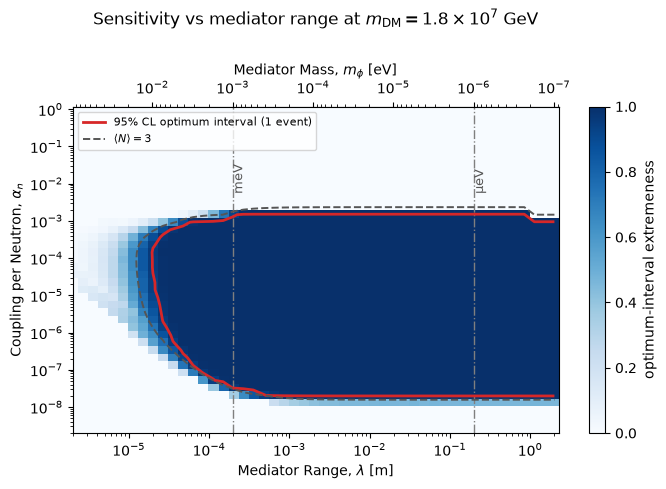

In [9]:
# best mass: where the reference-range coupling floor is deepest
floor = np.array([REF["alphas_n"][REF["extremeness"][:, im] >= CONFIDENCE].min()
                  if (REF["extremeness"][:, im] >= CONFIDENCE).any() else np.nan
                  for im in range(REF["ms"].size)])
M_BEST = float(REF["ms"][np.nanargmin(floor)])
print(f"best mass m_DM = {M_BEST:.2e} GeV "
      f"(floor alpha_n = {np.nanmin(floor):.2e} at {REF_TAG})")

LSCAN = Path("scan_lambda.npz")
if LSCAN.exists():
    dl = np.load(LSCAN)
    assert np.allclose(dl["events"], EVENTS)
    if not np.isclose(float(dl["m_dm"]), M_BEST, rtol=0.05):
        print(f"note: cache fixed m_DM = {float(dl['m_dm']):.2e} GeV")
    lambs_l, alphas_l = dl["lambs"], dl["alphas_n"]
    p_l, mu_l = dl["extremeness"], dl["counts"]
    m_fixed = float(dl["m_dm"])
    print(f"loaded {LSCAN}: {lambs_l.size} ranges x {alphas_l.size} couplings")
else:
    # coarse inline fallback through the same rate module
    lambs_l = np.geomspace(2e-6, 2.0, 13)
    alphas_l = np.logspace(-8.7, 0.0, 14)
    m_fixed = M_BEST
    p_l = np.zeros((alphas_l.size, lambs_l.size))
    mu_l = np.zeros_like(p_l)
    table_l = limits.new_table(seed=20260702)
    t0 = time.time()
    for il, lamb in enumerate(lambs_l):
        xs_l = rate.make_xsec(lamb, force_ln=True)
        for ia, a in enumerate(alphas_l):
            v_min = Q_THRESH / m_fixed / 10
            v_f_samples = atmosphere.compute_v_f_distribution(
                a, lamb, m_fixed, v_i_samples, v_min=v_min, n_grid=80)
            f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
            qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
            dr = rate.differential_rate_trapz(qs, a, m_fixed, f_v_f, xs_l)
            p_l[ia, il], mu_l[ia, il] = limits.extremeness_and_mu(
                table_l, EVENTS, qs, dr, T_TOTAL)
    print(f"inline lambda scan: {time.time() - t0:.0f}s "
          "(cache with scripts/scan_lambda.py)")

fig, ax = plt.subplots(figsize=(7, 5))
mesh = ax.pcolormesh(lambs_l, alphas_l, p_l, cmap="Blues", vmin=0, vmax=1,
                     shading="auto")
fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
CS95_L = ax.contour(lambs_l, alphas_l, p_l, levels=[CONFIDENCE],
                    colors="#d62728", linewidths=2)
ax.contour(lambs_l, alphas_l, mu_l, levels=[3.0], colors="#555555",
           linewidths=1.4, linestyles="--")
ax.plot([], [], color="#d62728", lw=2,
        label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} event)")
ax.plot([], [], color="#555555", lw=1.4, ls="--",
        label=r"$\langle N\rangle = 3$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Mediator Range, $\lambda$ [m]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
secax = ax.secondary_xaxis(
    "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                      lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV]")

# SI-prefix milestones that land inside the plotted mass window
SI_EV = [(1e-24, "yeV"), (1e-21, "zeV"), (1e-18, "aeV"), (1e-15, "feV"),
         (1e-12, "peV"), (1e-9, "neV"), (1e-6, "µeV"), (1e-3, "meV"),
         (1.0, "eV")]
lam_of_ev = lambda m_ev: 1e9 / units.conv_m2pGeV(1.0) / m_ev  # lambda [m]
for m_ev, name in SI_EV:
    lam_mark = lam_of_ev(m_ev)
    if lambs_l.min() < lam_mark < lambs_l.max():
        ax.axvline(lam_mark, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
        ax.text(lam_mark, 0.72, f" {name}", color="#555555", fontsize=9,
                ha="left", va="bottom", rotation=90,
                transform=ax.get_xaxis_transform())
e_b = int(np.floor(np.log10(m_fixed)))
ax.set_title(rf"Sensitivity vs mediator range at "
             rf"$m_{{\rm DM}} = {m_fixed / 10**e_b:.1f}\times10^{{{e_b}}}$ GeV",
             pad=28)
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig("limit_contour_lambda.png", dpi=140)

## Understanding the islands

*Everything in this section is pedagogical; none of it feeds the limit.*
Every edge has a one-line explanation (scalings at fixed exposure):

- **Left edge (kinematic floor).** Below
  $m = q_\text{th}/v_\text{esc} \approx 4.6\times10^6$ GeV even an
  escape-velocity particle cannot deliver the threshold kick, at any coupling.
- **Bottom edge (statistics floor).** The smallest coupling with
  $\mu \gtrsim 3$ expected events. The rate scales as
  $\alpha^2 n_\text{DM} \propto \alpha^2/m$, so the floor rises as
  $\alpha_\text{min} \propto \sqrt{m}$. Ranges with $\lambda \gtrsim$ mm share
  the same floor (Coulomb regime); shorter ranges pay the momentum-cap
  penalty, $\tilde q_\text{max} = K_1(\xi)$.
- **Top edge (atmospheric ceiling).** Stopping power also scales as
  $\alpha^2/m$: above the ceiling particles arrive below threshold speed, so
  the ceiling rises $\propto \sqrt{m}$ (up to a Coulomb log).
- **Right edge (reach saturation).** Once the impact parameters needed for a
  kick exceed $\lambda$, the reach grows only as $\lambda\ln\alpha$, the
  cross section saturates at $\sim\lambda^2$, and the falling number density
  $1/m$ wins: each factor of 10 in $\lambda$ buys roughly a factor of 100 in
  mass reach. No finite range reaches the Planck mass; only an exactly
  massless mediator (Coulomb reach $\propto \alpha$, unbounded) keeps the
  band open, as the maps below show.

The maps below make these statements visible for the reference range.


### Transit-count and reach maps up to the Planck mass

These maps are supplemental backup material; they are loaded from the
`flux_maps.npz` cache (regenerate with `python scripts/make_maps.py`) or
computed inline through the same `luhdm.rate.transit_maps` call when the
cache is absent.

**Top row:** color is $\log_{10} N_t$, the expected number of particles passing
within $\pi b_\text{max}^2$ during the exposure (halo flux, no attenuation;
the atmosphere only matters near the low-mass ceiling). White contours mark
decades of $N_t$ (the $N_t = 1$ line is drawn heavier); red: the 95% exclusion
contour from the scan. The
finite-range $N_t = 1$ boundary is a near-vertical wall (saturating reach);
a truly massless mediator's boundary is a $\sqrt{m}$ diagonal that continues
to the Planck mass.

**Bottom row:** the flux-averaged threshold reach
$b_\text{max} = \sqrt{\langle b^2 \rangle}$ in meters, with contours at
everyday length scales and the same red 95% exclusion contour overlaid, so
the reach along the sensitivity boundary can be read off directly. This is the aperture that converts flux into transits,
$N_t = \Phi \cdot \pi b_\text{max}^2 \cdot T$: for the massless mediator the
*formal* reach at large coupling is macroscopic
($b_\text{max} = 2\alpha/(q_\text{th} v)$), so flux quantization alone never
closes the band; the finite-range reach saturates near
$R_\text{eff} + \mathcal{O}(10)\lambda$, which is why its $N_t = 1$ wall is
real. Capping the massless reach at a laboratory scale $b_\text{cap}$ would
turn the falling flux into a hard, coupling-independent endpoint at
$m_\text{end} = \rho\,\bar v\,\pi b_\text{cap}^2\,T \approx
2.5\times10^{15}\ \text{GeV} \times (b_\text{cap}/10\,\text{cm})^2\,
(T/2\,\text{wk})$.


loaded flux_maps.npz


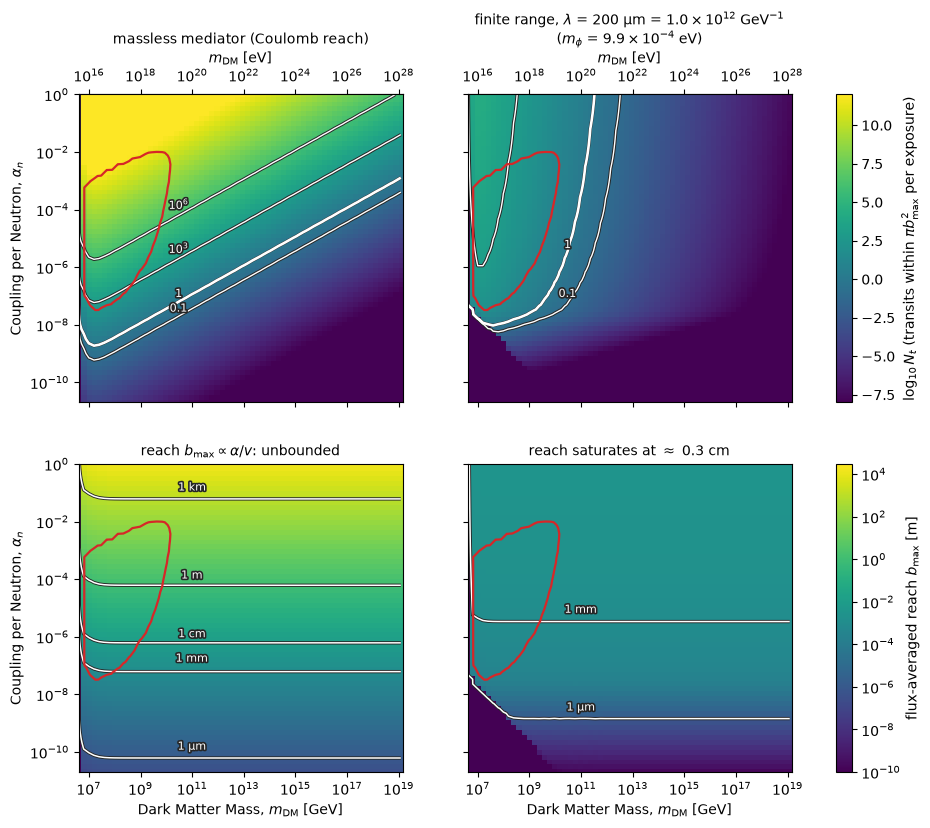

In [10]:
MAPS = Path("flux_maps.npz")
if MAPS.exists():
    dmap = np.load(MAPS)
    assert np.isclose(float(dmap["lamb"]), LAMB_REF) and \
        int(dmap["t_total"]) == T_TOTAL, "flux_maps.npz was made with other fiducials"
    ms_map, al_map = dmap["ms_map"], dmap["al_map"]
    NT_ML_MAP, B_ML_MAP = dmap["nt_massless"], dmap["b_massless"]
    NT_FR_MAP, B_FR_MAP = dmap["nt_finite"], dmap["b_finite"]
    print(f"loaded {MAPS}")
else:
    ms_map = np.geomspace(4e6, M_PLANCK, 64)
    al_map = np.geomspace(2e-11, 1.0, 64)
    t0 = time.time()
    NT_ML_MAP, B_ML_MAP = rate.transit_maps(ms_map, al_map, XS_MASSLESS, T_TOTAL)
    NT_FR_MAP, B_FR_MAP = rate.transit_maps(ms_map, al_map, XSEC[REF_TAG], T_TOTAL)
    print(f"computed maps inline in {time.time() - t0:.0f}s "
          "(cache with scripts/make_maps.py)")

import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm, Normalize

def outline(artists):  # keep white lines/labels legible on any viridis shade
    for a in artists:
        a.set_path_effects([pe.Stroke(linewidth=2.4, foreground="0.15"),
                            pe.Normal()])

def label_levels(ax, X_MAP, levels, names, m_ref=1e11):
    # label each level just above its line, mid-plot (the lines are close to
    # horizontal away from the kinematic floor)
    col = np.argmin(np.abs(ms_map - m_ref))
    for lev in levels:
        with np.errstate(divide="ignore"):
            miss = np.abs(np.log10(np.where(X_MAP[:, col] > 0,
                                            X_MAP[:, col], np.nan) / lev))
        if np.nanmin(miss) < 0.3:
            y = al_map[np.nanargmin(miss)]
            txt = ax.text(m_ref, y * 1.5, names[lev], fontsize=8, color="w",
                          ha="center", va="bottom")
            outline([txt])

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.8), sharex=True, sharey=True)
norm_nt = Normalize(vmin=-8, vmax=12)
norm_b = LogNorm(vmin=1e-10, vmax=3e4)
NT_LEVELS = [0.1, 1.0, 1e3, 1e6]
NT_NAMES = {0.1: "0.1", 1.0: "1", 1e3: "$10^3$", 1e6: "$10^6$"}
B_LEVELS = [1e-6, 1e-3, 1e-2, 1.0, 1e3]
B_NAMES = {1e-6: "1 µm", 1e-3: "1 mm", 1e-2: "1 cm", 1.0: "1 m", 1e3: "1 km"}
titles = ["massless mediator (Coulomb reach)",
          "finite range, " + lamb_label(LAMB_REF) + "\n(" +
          mphi_label(LAMB_REF) + ")"]

for j, (NT_MAP, B_MAP) in enumerate([(NT_ML_MAP, B_ML_MAP),
                                     (NT_FR_MAP, B_FR_MAP)]):
    ax = axes[0, j]
    z = np.log10(np.clip(NT_MAP, 1e-8, 1e12))
    mesh_nt = ax.pcolormesh(ms_map, al_map, z, cmap="viridis", norm=norm_nt,
                            shading="auto")
    cs = ax.contour(ms_map, al_map, NT_MAP, levels=NT_LEVELS, colors="w",
                    linewidths=[1.0 if lev != 1.0 else 1.9
                                for lev in NT_LEVELS])
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, NT_MAP, NT_LEVELS, NT_NAMES, m_ref=3e10)
    ax.set_title(titles[j], fontsize=10)

    ax = axes[1, j]
    mesh_b = ax.pcolormesh(ms_map, al_map, np.clip(B_MAP, 1e-10, None),
                           cmap="viridis", norm=norm_b, shading="auto")
    cs = ax.contour(ms_map, al_map, B_MAP, levels=B_LEVELS, colors="w",
                    linewidths=1.1)
    outline(getattr(cs, "collections", [cs]))
    label_levels(ax, B_MAP, B_LEVELS, B_NAMES)
    note = (r"reach $b_{\rm max} \propto \alpha/v$: unbounded" if j == 0 else
            rf"reach saturates at $\approx$ {B_MAP.max() * 100:.1f} cm")
    ax.set_title(note, fontsize=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV]")

# overlay the reference 95% contour on every panel
for i in (0, 1):
    for j in (0, 1):
        axes[i, j].contour(REF["ms"], REF["alphas_n"], REF["extremeness"],
                           levels=[CONFIDENCE], colors="#d62728",
                           linewidths=1.6)

for ax in axes[:, 0]:
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
axes[0, 0].set_ylim(al_map[0], 1.0)
for j in (0, 1):
    sec = axes[0, j].secondary_xaxis(
        "top", functions=(lambda x: x * 1e9, lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV]")
fig.colorbar(mesh_nt, ax=axes[0, :], label=r"$\log_{10} N_t$ (transits within "
                                           r"$\pi b_{\rm max}^2$ per exposure)")
fig.colorbar(mesh_b, ax=axes[1, :],
             label=r"flux-averaged reach $b_{\rm max}$ [m]")
fig.savefig("flux_map.png", dpi=140, bbox_inches="tight")

## Machine-readable output

Everything on the plots, written to `limit_contour_data.npz` so nobody ever
has to digitize a figure: per-range grids and surfaces (keys suffixed by the
range tag), the event list, the 95% contours as NaN-separated
(m, alpha_n) polylines, and the Planck-range understanding maps.


In [11]:
def contour_polyline(cs):
    # all segments of a single-level contour as one NaN-separated (N, 2) array
    parts = []
    for seg in cs.allsegs[0]:
        parts.append(seg)
        parts.append(np.full((1, 2), np.nan))
    return np.vstack(parts) if parts else np.empty((0, 2))


out = dict(events=EVENTS, t_total=T_TOTAL, confidence=CONFIDENCE,
           lambdas=np.array([l for _, l, _ in LAMBDAS]))
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    out[f"ms_{tag}"] = s["ms"]
    out[f"alphas_n_{tag}"] = s["alphas_n"]
    out[f"extremeness_{tag}"] = s["extremeness"]
    out[f"counts_{tag}"] = s["counts"]
    out[f"n_transit_{tag}"] = s["n_transit"]
    if tag in CS95:
        out[f"contour_95_{tag}"] = contour_polyline(CS95[tag])
out["contour_n3_200um"] = contour_polyline(cs3)
out["lambda_scan_lambs"] = lambs_l
out["lambda_scan_alphas"] = alphas_l
out["lambda_scan_extremeness"] = p_l
out["lambda_scan_counts"] = mu_l
out["lambda_scan_m_dm"] = m_fixed
if len(CS95_L.allsegs[0]):
    out["contour_95_lambda"] = contour_polyline(CS95_L)
out["nt_map_ms"] = ms_map
out["nt_map_alphas"] = al_map
out["nt_map_massless"] = NT_ML_MAP
out["nt_map_finite"] = NT_FR_MAP
out["b_map_massless"] = B_ML_MAP
out["b_map_finite"] = B_FR_MAP
np.savez("limit_contour_data.npz", **out)
d = np.load("limit_contour_data.npz")
print("limit_contour_data.npz:", len(d.files), "arrays")
print(sorted(d.files))

limit_contour_data.npz: 63 arrays
['alphas_n_10um', 'alphas_n_200um', 'alphas_n_20um', 'alphas_n_2cm', 'alphas_n_2m', 'alphas_n_2mm', 'alphas_n_2um', 'alphas_n_massless', 'b_map_finite', 'b_map_massless', 'confidence', 'contour_95_200um', 'contour_95_20um', 'contour_95_2cm', 'contour_95_2m', 'contour_95_2mm', 'contour_95_lambda', 'contour_95_massless', 'contour_n3_200um', 'counts_10um', 'counts_200um', 'counts_20um', 'counts_2cm', 'counts_2m', 'counts_2mm', 'counts_2um', 'counts_massless', 'events', 'extremeness_10um', 'extremeness_200um', 'extremeness_20um', 'extremeness_2cm', 'extremeness_2m', 'extremeness_2mm', 'extremeness_2um', 'extremeness_massless', 'lambda_scan_alphas', 'lambda_scan_counts', 'lambda_scan_extremeness', 'lambda_scan_lambs', 'lambda_scan_m_dm', 'lambdas', 'ms_10um', 'ms_200um', 'ms_20um', 'ms_2cm', 'ms_2m', 'ms_2mm', 'ms_2um', 'ms_massless', 'n_transit_10um', 'n_transit_200um', 'n_transit_20um', 'n_transit_2cm', 'n_transit_2m', 'n_transit_2mm', 'n_transit_2um', 'n

## Appendix: validation checks

1. **$K_1$ → Coulomb convergence.** At $\lambda$ = 2 m and small coupling
   (threshold kicks come from close flybys, $b \ll \lambda$, the Coulomb
   regime), the tabulated $K_1$ machinery must reproduce the closed form
   $2\pi\alpha^2/(v^2 q^3)$. The ratios below should be $\approx 1$.
2. **Log-space vs direct.** The two shortest ranges use the log-space
   tabulation; `tests/test_cross_section_ln.py` pins agreement with Dorian's
   direct code at the percent level wherever both are healthy
   ($\xi \le 10$ across the tabulated range), and finiteness at $\xi = 1000$
   where the direct $K_1$ underflows. Run `pytest` to reproduce.
3. **Spot checks along the reference contour.** The reach $b_\text{max}$, the
   transit count $N_t$, and $\mu$ at ten points on the 95% boundary. Expect
   $N_t \ge \mu \gtrsim 3$ everywhere (exclusion is never claimed where no
   particle is expected to pass within reach) and $b_\text{max}$ far below
   the apparatus scale, so the point-sensor impulse model is safe on the
   boundary.


In [12]:
# validate: K1 machinery at lambda = 2 m vs the analytic Coulomb projection.
# Coulomb regime requires b << lambda, i.e. q_tilde >> 1: pick a small coupling
# so threshold kicks come from close flybys.
xs_ml = XSEC["2m"]
alpha_chk = 1e-6 * config.N_NEUTRONS
v_chk = 1e-3
qs_chk = np.geomspace(Q_THRESH, 10 * Q_THRESH, 6)
num = rate.dsigma_dq_any(qs_chk, alpha_chk, v_chk, xs_ml)
ana = cross_section.cross_section_rutherford_projection(qs_chk, alpha_chk, v_chk)
print("K1 machinery / analytic (should be ~1):", np.round(num / ana, 4))

K1 machinery / analytic (should be ~1): [1.0176 1.0187 1.0172 1.0126 1.0046 1.002 ]


In [13]:
poly = contour_polyline(cs95)
pts = poly[~np.isnan(poly).any(axis=1)]
idx = np.linspace(0, len(pts) - 1, 10).astype(int)
xs_ref = XSEC[REF_TAG]

print(f"{'m [GeV]':>10} {'alpha_n':>9} {'max b_max [cm]':>14} {'N_transit':>10} {'mu':>7}")
for m, a in pts[idx]:
    v_min = Q_THRESH / m / 10
    v_f_samples = atmosphere.compute_v_f_distribution(
        a, LAMB_REF, m, v_i_samples, v_min=v_min, n_grid=80)
    f_v_f = atmosphere.compute_f_vf(v_f_samples, v_min)[0]
    alpha = a * config.N_NEUTRONS
    vs = np.geomspace(max(Q_THRESH / m, 1e-8), config.VESC, 300)
    b = cross_section.impact_parameter_max(Q_THRESH, alpha, LAMB_REF, R_eff, vs)
    n_transit = expected_transits(a, m, f_v_f, xs_ref)
    qs = np.geomspace(Q_THRESH, 1e4 * Q_THRESH, 200)
    drdq_vals = differential_rate_trapz(qs, a, m, f_v_f, xs_ref)
    mu = np.trapezoid(drdq_vals, qs) * T_TOTAL
    print(f"{m:>10.2e} {a:>9.1e} {b.max() * 100:>14.2f} {n_transit:>10.1f} {mu:>7.2f}")
print("\nN_transit >= mu everywhere: exclusion is never claimed where fewer "
      "than ~3 particles are expected within reach.")

   m [GeV]   alpha_n max b_max [cm]  N_transit      mu


  1.82e+07   3.2e-08           0.03       73.2    3.55


  2.58e+08   1.3e-07           0.10       22.1    5.48


  1.97e+09   2.2e-06           0.19       12.1    4.44


  6.94e+09   5.6e-05           0.28        9.3    3.74


...

  9.56e+08   6.7e-03           0.33       24.2    6.47


  2.99e+07   1.5e-03           0.24      196.3   19.36


  6.63e+06   9.0e-05           0.15     1741.5   25.86


  6.63e+06   8.5e-07           0.07      360.3    9.43


  1.82e+07   3.2e-08           0.03       73.2    3.55

N_transit >= mu everywhere: exclusion is never claimed where fewer than ~3 particles are expected within reach.


## Notes

- **Data**: replace `EVENTS` and rerun. More candidates only move the
  extremeness surfaces; the machinery is untouched.
- **Physics tweaks** happen in `luhdm/rate.py` (the rate formula and reach)
  and in this notebook (the halo/attenuation calls, the `LAMBDAS` list, the
  grids, `T_TOTAL`).
- **Knobs**: `n_grid` (attenuation ODE resolution, the runtime driver),
  `n_mc` / `mu_dex` in `limits.extremeness_and_mu`, and the grid densities.
- `limit_contour_data.npz` is the plottable record of the figures; the
  `scan7_<tag>.npz` files (from `scripts/scan_grid.py`) and `flux_maps.npz`
  (from `scripts/make_maps.py`) are caches; delete them to recompute inline.
  All three code paths go through `luhdm/rate.py`, so notebook and scripts
  cannot drift. The transit/reach maps use the raw halo flux (no
  attenuation); they are for understanding, not inputs to the limit.
- With zero events the extremeness contour coincides with
  $\langle N\rangle \simeq 3$ at 95% CL by construction, so the old rule is
  recovered exactly in the background-free case.
